# Layer 1 — What is normal?

**Business case.** The **hirer** — a talent-acquisition lead at a Singapore SME — is about to post
a vacancy on MyCareersFuture and must set three things: **pay range**, **minimum years of
experience**, and **position level**.

This notebook answers the first half of that decision — *is the configuration I am about to post a
normal one?* — using **all 1,044,587 postings** (Mar 2023 – May 2024).

It deliberately does **not** touch applicant response. That is Layer 2, and it runs on a much
smaller cohort for reasons documented in §1.

| | Layer 1 (this notebook) | Layer 2 (`hirer_layer2_analysis.ipynb`) |
|---|---|---|
| Question | What do comparable employers offer? | What response did it get? |
| Rows | 1,044,587 (all) | 118,749 (`counters_complete`, see §1.1) |
| Window | Mar 2023 – May 2024 | Mar – Jun 2023 |

**Outputs:** a benchmark table keyed on `sector × position_level × experience_level` (`bench_3`),
a `salary_lookup()` helper that falls back on thin cells, and a competition-density
measure (`density`). These stay in-notebook — wiring them into the dashboard is a separate step.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/processed/jobs_enriched.parquet'

MIN_N       = 30   # smallest cell we are willing to quote a benchmark from
WARMUP_DAYS = 30   # discarded from the competition-density series (see s.5)

# The date at which engagement counters stop being trustworthy. INFERRED from the data,
# not recorded anywhere -- s.1 shows the evidence and the reasoning.
CRAWL_DATE = '2023-07-01'

df = pd.read_parquet(DATA_PATH)
print(f'{len(df):,} postings x {df.shape[1]} columns')
print(f'posting_date spans {df.posting_date.min():%Y-%m-%d} to {df.posting_date.max():%Y-%m-%d}')

1,044,587 postings x 31 columns
posting_date spans 2023-03-28 to 2024-05-29


## 1. Scope — which columns are usable here, and why

### The observed pattern (fact)

The cell below prints three things about the engagement counters:

1. Median `views` collapses from **51 to 2** between Jun and Jul 2023, then stays in the low
   single digits (2–6) for the remaining eleven months.
2. **92.6% of rows still marked `Open` have an `expiry_date` that has already passed** — those
   listings cannot still be open, so `status_jobStatus` is not current.
3. Older postings show **fewer** views than newer ones (Jul 2023 median 2, Apr 2024 median 6).

Point 3 is the decisive one. A posting from Jul 2023 has had ten extra months to accumulate views
and has fewer of them. No "the data is simply old" explanation produces that ordering.

### The explanation (inference)

The most parsimonious account is that the file concatenates **two collection regimes**:

| | Posting dates | Engagement counters |
|---|---|---|
| **Complete-counter cohort** | Mar – Jun 2023 | Complete, for postings that expired before ~2023-07-01 |
| **Capture-at-posting cohort** | Jul 2023 – May 2024 | Frozen at roughly day 0 of the posting's life |

**This is an inference, not documented provenance.** The raw file has 22 columns and none of them
records a capture date or a source, so there is no field to verify it against. What is certain is
the pattern above; the two-regime story is how we account for it. `CRAWL_DATE` is our estimate of
where the boundary falls, and §1.1 materialises it as a column so the split is at least inspectable.

### The consequence for this notebook

Every column recorded *when the posting was written* is valid across all 1.04M rows. Every column
that *accumulates over the life of the posting* is frozen at capture time and is unusable outside
Layer 2's cohort. Layer 1 uses **all** rows precisely because it touches only the former.

In [2]:
# Columns valid at full scale -- these describe the posting as written.
POSTING_TIME_COLS = [
    'sector', 'sub_sector', 'position_level', 'experience_level', 'seniority_years',
    'salary_min', 'salary_max', 'salary_midpoint', 'salary_flag',
    'job_type', 'vacancies', 'listing_days', 'posting_date', 'expiry_date',
    'company', 'title', 'metadata_isPostedOnBehalf',
]

# Columns frozen at capture time -- MUST NOT be used in Layer 1.
CAPTURE_TIME_COLS = ['applications', 'views', 'status_jobStatus', 'repost_count', 'is_repost']

# Demonstrate the hazard rather than assert it: mean views by posting month.
chk = df.groupby(df.posting_date.dt.to_period('M'), observed=True).agg(
    n=('views', 'size'), median_views=('views', 'median'), median_apps=('applications', 'median'))
print(chk.to_string())
print('\nOpen rows whose expiry has already passed: '
      f'{(df.loc[df.status_jobStatus == "Open", "expiry_date"] < df.posting_date.max()).mean():.1%}')

                  n  median_views  median_apps
posting_date                                  
2023-03       10085          62.0          3.0
2023-04       27511          70.0          3.0
2023-05       74863          75.0          4.0
2023-06       85631          51.0          2.0
2023-07       86073           2.0          0.0
2023-08       85434           2.0          0.0
2023-09       76962           2.0          0.0
2023-10       80139           3.0          0.0
2023-11       72586           2.0          0.0
2023-12       61067           2.0          0.0
2024-01       80854           2.0          0.0
2024-02       69081           3.0          0.0
2024-03       79518           4.0          0.0
2024-04       81627           6.0          0.0
2024-05       73156           4.0          0.0

Open rows whose expiry has already passed: 92.6%


The `median_views` column above is the whole argument in one table: it drops off a cliff at
2023-07 and never recovers. Anything downstream of it is Layer 2 territory.

### 1.1 Deduplication and the cohort flag

5.4% of rows are same-day duplicate listings (`dup_group_size > 1`). Both copies are real rows in
the file, so dropping every flagged row would delete the original too — we keep **one row per
`dup_group_id`**. This matters for Layer 1 specifically, because duplicates inflate posting volume
and therefore the competition-density measure in §5.

The same cell also materialises the `CRAWL_DATE` boundary from §1 as a `counters_complete`
column, so the two collection regimes stay inspectable — this is the flag Layer 2 selects on.

In [3]:
mkt = df.drop_duplicates(subset='dup_group_id', keep='first').copy()
print(f'{len(df):,} rows -> {len(mkt):,} after dedup ({len(df) - len(mkt):,} duplicate copies removed)')

# Materialise the inferred boundary as a column, so the two cohorts are inspectable rather
# than existing only in prose. Layer 1 does NOT filter on this -- it is documentation, and
# the flag Layer 2 will select on.
mkt['counters_complete'] = mkt.expiry_date <= pd.Timestamp(CRAWL_DATE)

print(f'\ncounters_complete=True  {mkt.counters_complete.sum():>9,}  '
      f'(expired before {CRAWL_DATE} -- engagement counters usable, this is the Layer 2 pool)')
print(f'counters_complete=False {(~mkt.counters_complete).sum():>9,}  '
      f'(counters frozen near posting -- posting-time columns still valid)')

1,044,587 rows -> 1,009,709 after dedup (34,878 duplicate copies removed)

counters_complete=True    118,749  (expired before 2023-07-01 -- engagement counters usable, this is the Layer 2 pool)
counters_complete=False   890,960  (counters frozen near posting -- posting-time columns still valid)


### 1.2 How salary is reported

Every salary figure below is reported as **actual dollar percentiles of `salary_midpoint`** — the
centre of the advertised range — rather than as a categorical band label.

Band labels compress a range into a single word, and on this data they do it badly: the advertised
floor and ceiling routinely fall in different bands, so whichever endpoint a label is cut on, it
contradicts part of the range it claims to summarise. Dollar percentiles carry that spread directly
and need no such caveat, so the notebook uses them throughout.

## 2. Market shape — what is being posted at all

Posting counts are recorded at posting time, so this section is valid across the full 15 months.
It sizes the comparison pool: if the hirer's sector or level barely appears, no benchmark below
will be trustworthy for them.

The salary medians here are computed before §3 introduces its salary filter. That is safe:
undisclosed salaries carry no midpoint at all, and medians are insensitive to the few extremes
the filter removes, so the per-level figures move by at most \$50 either way.

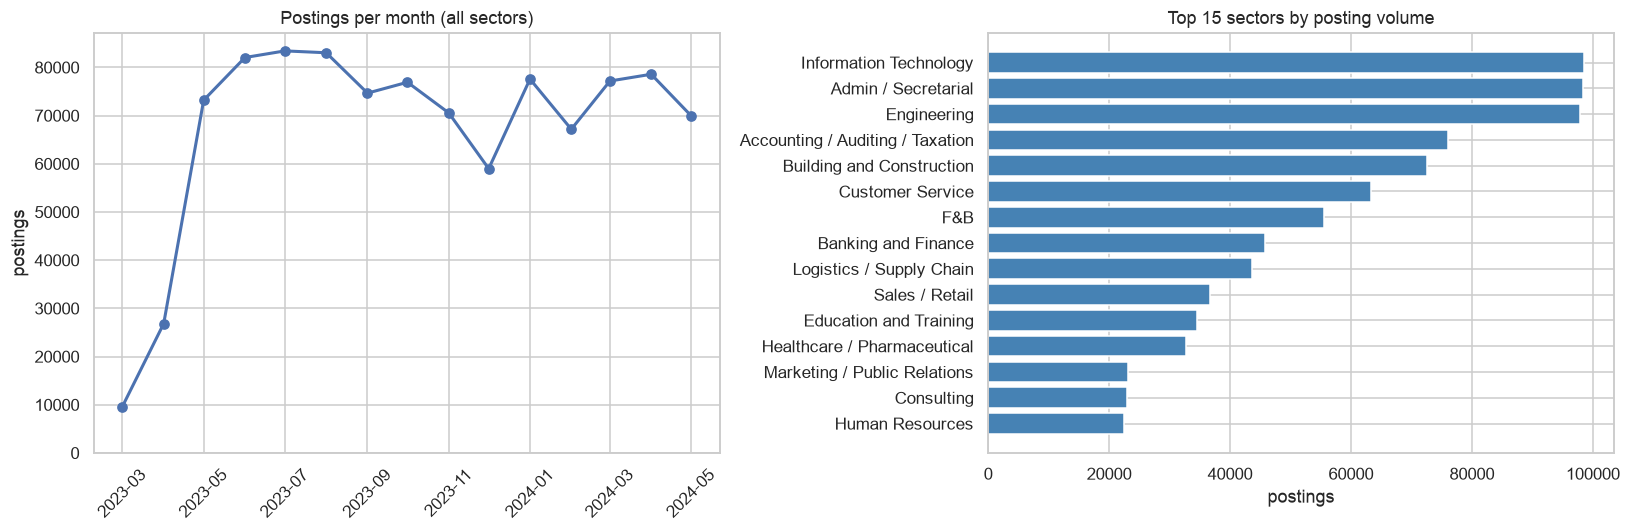

Mar 2023 and May 2024 are partial months -- the dip at each end is coverage, not demand.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

vol = mkt.groupby(mkt.posting_date.dt.to_period('M'), observed=True).size()
vol.index = vol.index.to_timestamp()
axes[0].plot(vol.index, vol.values, marker='o', lw=2)
axes[0].set_title('Postings per month (all sectors)')
axes[0].set_ylabel('postings')
axes[0].set_ylim(bottom=0)
axes[0].tick_params(axis='x', rotation=45)

top_sec = mkt.sector.value_counts().head(15).sort_values()
axes[1].barh(top_sec.index, top_sec.values, color='steelblue')
axes[1].set_title('Top 15 sectors by posting volume')
axes[1].set_xlabel('postings')

plt.tight_layout()
plt.show()

print('Mar 2023 and May 2024 are partial months -- the dip at each end is coverage, not demand.')

In [5]:
shape = pd.DataFrame({
    'postings': mkt.position_level.value_counts(),
    'share_%': (mkt.position_level.value_counts(normalize=True) * 100).round(1),
    'median_years': mkt.groupby('position_level', observed=True).seniority_years.median(),
    'median_salary_midpoint': mkt.groupby('position_level', observed=True).salary_midpoint.median(),
}).sort_values('postings', ascending=False)
shape.index = shape.index.astype(str)

# Total row. The medians are recomputed over the whole market -- averaging the per-level
# medians would be wrong, since the levels differ enormously in size.
shape.loc['All levels'] = {
    'postings': len(mkt),
    'share_%': 100.0,
    'median_years': mkt.seniority_years.median(),
    'median_salary_midpoint': mkt.salary_midpoint.median(),
}
shape['postings'] = shape['postings'].astype(int)
shape

,postings,share_%,median_years,median_salary_midpoint
position_level,,,,
Executive,246817,24.4,2.0,3750.0
Junior Executive,163644,16.2,1.0,3150.0
Non-executive,128327,12.7,1.0,2700.0
Fresh/entry level,111980,11.1,0.0,2600.0
Manager,108561,10.8,5.0,6050.0
Professional,104311,10.3,4.0,6500.0
Senior Executive,97932,9.7,3.0,5000.0
Middle Management,25540,2.5,5.0,7000.0
Senior Management,22597,2.2,7.0,9500.0


## 3. Salary benchmarks

The core deliverable: for a given `sector × position_level × experience_level`, what does the
market actually pay?

**Base filter.** We use `salary_flag == 'ok'`, the pipeline's own rule, which removes undisclosed
salaries and flagged outliers. That rule is loose — a few hundred postings above \$30k/month
survive it — so we report **percentiles, never means**. Percentiles are insensitive to the residual
extremes, which is the cheapest defensible fix.

In [6]:
sal = mkt[mkt.salary_flag == 'ok'].copy()
for c in ['salary_min', 'salary_max', 'salary_midpoint']:
    sal[c] = sal[c].astype('float64')

print(f'{len(sal):,} postings with usable salary '
      f'({len(sal) / len(mkt):.1%} of the deduplicated market)')
print(f'residual extremes surviving salary_flag: '
      f'{(sal.salary_midpoint > 30000).sum():,} postings above $30k/month')

999,941 postings with usable salary (99.0% of the deduplicated market)
residual extremes surviving salary_flag: 404 postings above $30k/month


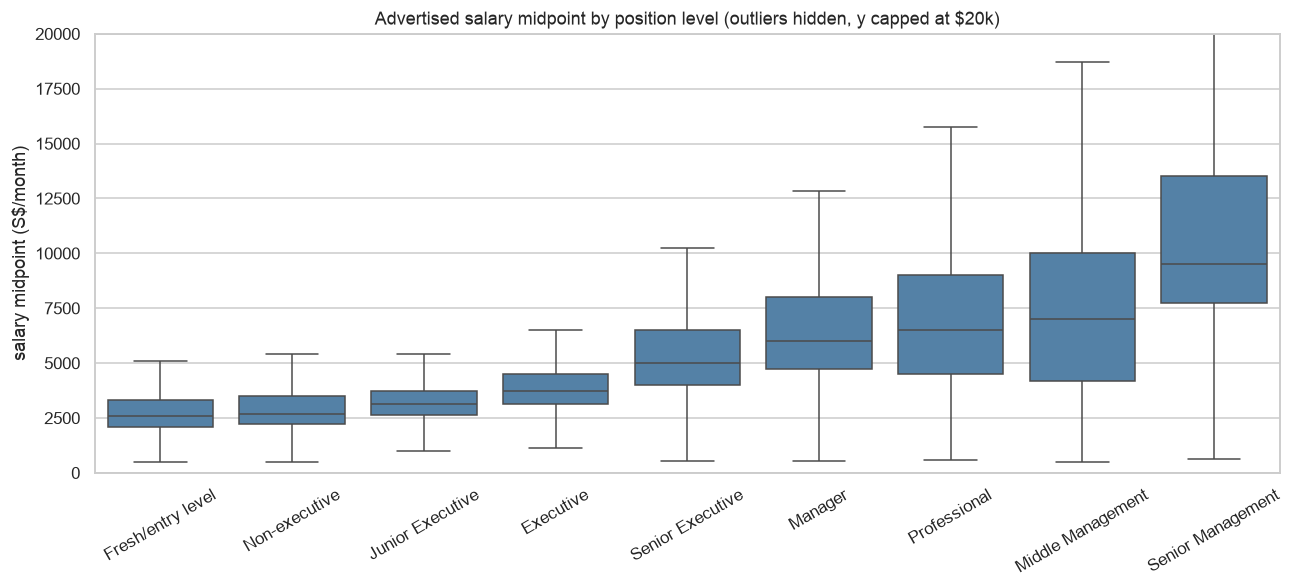

In [7]:
# Salary spread by position level -- the single most useful orientation chart for the hirer,
# so it comes before the benchmark tables it summarises.
order = (mkt.groupby('position_level', observed=True).salary_midpoint.median()
            .sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(12, 5.5))
sns.boxplot(data=sal, x='position_level', y='salary_midpoint', order=order,
            showfliers=False, color='steelblue', ax=ax)
ax.set_ylim(0, 20000)
ax.set_title('Advertised salary midpoint by position level (outliers hidden, y capped at $20k)')
ax.set_xlabel('')
ax.set_ylabel('salary midpoint (S$/month)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

In [8]:
def benchmark(frame, keys, min_n=MIN_N):
    """Salary percentiles per cell, suppressing cells too small to quote."""
    out = frame.groupby(keys, observed=True).agg(
        n=('salary_midpoint', 'size'),
        mid_p25=('salary_midpoint', lambda s: s.quantile(.25)),
        mid_p50=('salary_midpoint', 'median'),
        mid_p75=('salary_midpoint', lambda s: s.quantile(.75)),
        min_p50=('salary_min', 'median'),
        max_p50=('salary_max', 'median'),
        yrs_p50=('seniority_years', 'median'),
    ).round(0)
    return out[out.n >= min_n].sort_values('n', ascending=False)


KEYS_3 = ['sector', 'position_level', 'experience_level']
KEYS_2 = ['sector', 'position_level']

bench_3 = benchmark(sal, KEYS_3)
bench_2 = benchmark(sal, KEYS_2)

for name, tbl in [('sector+level+experience', bench_3), ('sector+level', bench_2)]:
    print(f'{name:26s} {len(tbl):4d} cells >= {MIN_N} postings, '
          f'covering {tbl.n.sum() / len(sal):.1%} of postings')

bench_3.head(10)

sector+level+experience     867 cells >= 30 postings, covering 99.7% of postings
sector+level                370 cells >= 30 postings, covering 100.0% of postings


,,,n,mid_p25,mid_p50,mid_p75,min_p50,max_p50,yrs_p50
sector,position_level,experience_level,,,,,,,
Admin / Secretarial,Fresh/entry level,Entry Level,17998,2000.0,2350.0,2950.0,2000.0,2640.0,0.0
Engineering,Executive,Mid Level,17885,3500.0,4000.0,4900.0,3500.0,4800.0,2.0
Admin / Secretarial,Junior Executive,Entry Level,16867,2300.0,2650.0,3000.0,2300.0,3000.0,1.0
Information Technology,Professional,Senior,15577,7500.0,9000.0,11000.0,7000.0,10500.0,6.0
Building and Construction,Executive,Mid Level,15546,3500.0,4000.0,4500.0,3000.0,4800.0,3.0
Information Technology,Executive,Mid Level,15483,4000.0,5250.0,6500.0,4000.0,6000.0,3.0
Accounting / Auditing / Taxation,Executive,Mid Level,14744,3150.0,3500.0,4050.0,3000.0,4000.0,2.0
Admin / Secretarial,Executive,Mid Level,12925,2800.0,3250.0,3750.0,2800.0,3600.0,2.0
Information Technology,Professional,Mid Level,12291,5750.0,7000.0,8750.0,5700.0,8500.0,3.0


99.7% of postings fall in a three-key cell with at least 30 comparables, so the fine grain is
almost always available. The fallback below exists for the residual tail.

In [9]:
GLOBAL_FALLBACK = {
    'n': len(sal),
    'mid_p25': sal.salary_midpoint.quantile(.25),
    'mid_p50': sal.salary_midpoint.median(),
    'mid_p75': sal.salary_midpoint.quantile(.75),
}


def salary_lookup(sector, position_level, experience_level=None):
    """Benchmark for one configuration, degrading gracefully when a cell is too thin.

    Returns the finest grain that clears MIN_N, and always reports which grain was used
    so the dashboard can show the hirer how specific the comparison actually is.
    """
    if experience_level is not None and (sector, position_level, experience_level) in bench_3.index:
        row = bench_3.loc[(sector, position_level, experience_level)]
        return {'grain': 'sector + level + experience', **row.to_dict()}
    if (sector, position_level) in bench_2.index:
        row = bench_2.loc[(sector, position_level)]
        return {'grain': 'sector + level', **row.to_dict()}
    return {'grain': 'all postings (no comparable cell)', **GLOBAL_FALLBACK}


for q in [('Engineering', 'Executive', 'Mid Level'),
          ('Information Technology', 'Professional', 'Senior'),
          ('Engineering', 'Senior Management', 'Entry Level')]:
    r = salary_lookup(*q)
    print(f'{q[0]} / {q[1]} / {q[2]}')
    print(f'   grain={r["grain"]}  n={int(r["n"]):,}  '
          f'P25=${r["mid_p25"]:,.0f}  median=${r["mid_p50"]:,.0f}  P75=${r["mid_p75"]:,.0f}\n')

Engineering / Executive / Mid Level
   grain=sector + level + experience  n=17,885  P25=$3,500  median=$4,000  P75=$4,900

Information Technology / Professional / Senior
   grain=sector + level + experience  n=15,577  P25=$7,500  median=$9,000  P75=$11,000

Engineering / Senior Management / Entry Level
   grain=sector + level  n=1,000  P25=$7,550  median=$10,750  P75=$14,000



## 4. Configuration norms — is this combination one that anyone else posts?

The hirer sets **years of experience** and **position level** independently, and nothing in the
posting form stops them from pairing "8 years" with "Fresh/entry level". This section shows which
pairings the market actually uses, so the dashboard can warn on incoherent ones.

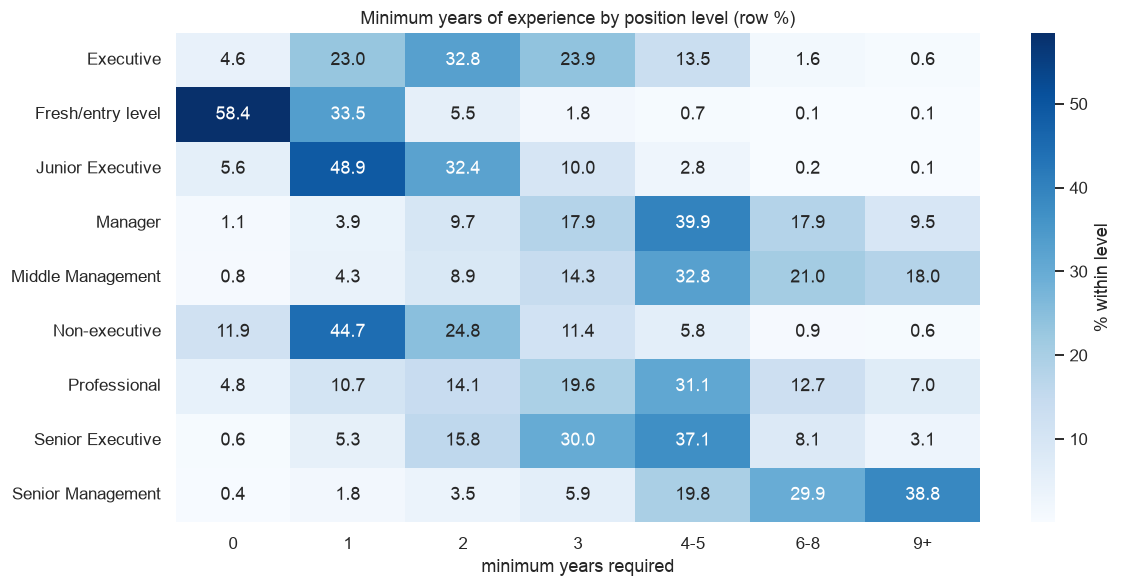

In [10]:
YR_BINS = [-1, 0, 1, 2, 3, 5, 8, 100]
YR_LABELS = ['0', '1', '2', '3', '4-5', '6-8', '9+']
mkt['yrs_bucket'] = pd.cut(mkt.seniority_years, YR_BINS, labels=YR_LABELS)

norms = pd.crosstab(mkt.position_level, mkt.yrs_bucket, normalize='index') * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.heatmap(norms, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '% within level'}, ax=ax)
ax.set_title('Minimum years of experience by position level (row %)')
ax.set_xlabel('minimum years required')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [11]:
# Combinations the market essentially never uses -- candidates for a dashboard warning.
rare = norms.stack()
rare = rare[rare < 1.0].sort_values()
rare.name = 'share_within_level_%'
print(f'{len(rare)} of {norms.size} level x years combinations are used by <1% of postings '
      'at that level:\n')
print(rare.round(2).to_string())

11 of 63 level x years combinations are used by <1% of postings at that level:

position_level     yrs_bucket
Fresh/entry level  9+            0.06
                   6-8           0.08
Junior Executive   9+            0.11
                   6-8           0.22
Senior Management  0             0.42
Non-executive      9+            0.59
Executive          9+            0.60
Senior Executive   0             0.62
Fresh/entry level  4-5           0.68
Middle Management  0             0.78
Non-executive      6-8           0.88


## 5. Competition density — how crowded will the posting be?

A configuration can be perfectly normal and still fill slowly because a hundred identical postings
are live at the same time. Density is computable from posting and expiry dates alone, so — unlike
applicant response — it is available across the **entire 15-month window**.

Method: `+1` on each posting date, `-1` on each expiry date, cumulative sum per
`sector × position_level`. The first 30 days are discarded: postings made *before* the data begins
are invisible to us, so the series ramps from an artificial zero.

In [12]:
GROUP_KEYS = ['sector', 'position_level']

starts = mkt.groupby(GROUP_KEYS + ['posting_date'], observed=True).size().reset_index(name='delta')
ends = mkt.groupby(GROUP_KEYS + ['expiry_date'], observed=True).size().reset_index(name='delta')
ends['delta'] = -ends['delta']
ends = ends.rename(columns={'expiry_date': 'posting_date'})

events = (pd.concat([starts, ends])
            .groupby(GROUP_KEYS + ['posting_date'], observed=True).delta.sum().reset_index())

all_days = pd.date_range(mkt.posting_date.min(), mkt.expiry_date.max(), freq='D')
live = (events.pivot_table(index='posting_date', columns=GROUP_KEYS, values='delta',
                           aggfunc='sum', observed=True)
              .reindex(all_days).fillna(0).cumsum())

valid_window = live.loc[mkt.posting_date.min() + pd.Timedelta(days=WARMUP_DAYS):
                        mkt.posting_date.max()]
print(f'live-postings matrix: {live.shape[0]} days x {live.shape[1]} sector-level cells')
print(f'density measured over {valid_window.index.min():%Y-%m-%d} '
      f'to {valid_window.index.max():%Y-%m-%d}')

live-postings matrix: 459 days x 387 sector-level cells
density measured over 2023-04-27 to 2024-05-29


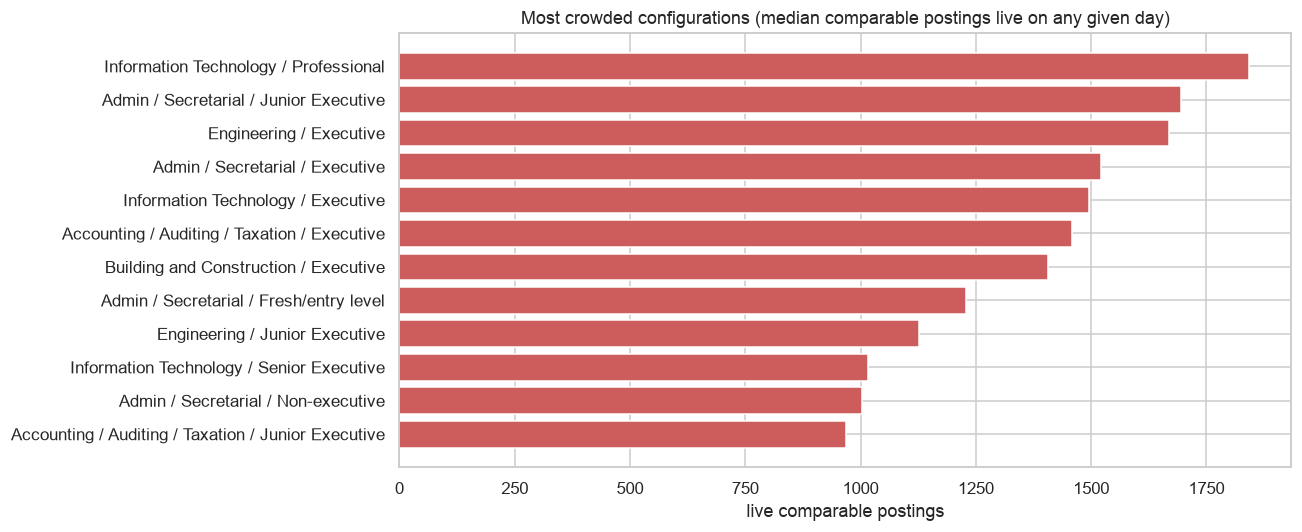

                          sector    position_level  median_live_comparables
          Information Technology      Professional                   1842.0
             Admin / Secretarial  Junior Executive                   1695.0
                     Engineering         Executive                   1668.0
             Admin / Secretarial         Executive                   1521.0
          Information Technology         Executive                   1496.0
Accounting / Auditing / Taxation         Executive                   1459.0
       Building and Construction         Executive                   1407.0
             Admin / Secretarial Fresh/entry level                   1229.0
                     Engineering  Junior Executive                   1126.0
          Information Technology  Senior Executive                   1016.0
             Admin / Secretarial     Non-executive                   1003.0
Accounting / Auditing / Taxation  Junior Executive                    969.0


In [13]:
density = (valid_window.median().rename('median_live_comparables')
                       .reset_index()
                       .sort_values('median_live_comparables', ascending=False))

fig, ax = plt.subplots(figsize=(12, 5))
top = density.head(12).iloc[::-1]
labels = top.sector.astype(str) + ' / ' + top.position_level.astype(str)
ax.barh(labels, top.median_live_comparables, color='indianred')
ax.set_title('Most crowded configurations (median comparable postings live on any given day)')
ax.set_xlabel('live comparable postings')
plt.tight_layout()
plt.show()

print(density.head(12).to_string(index=False))

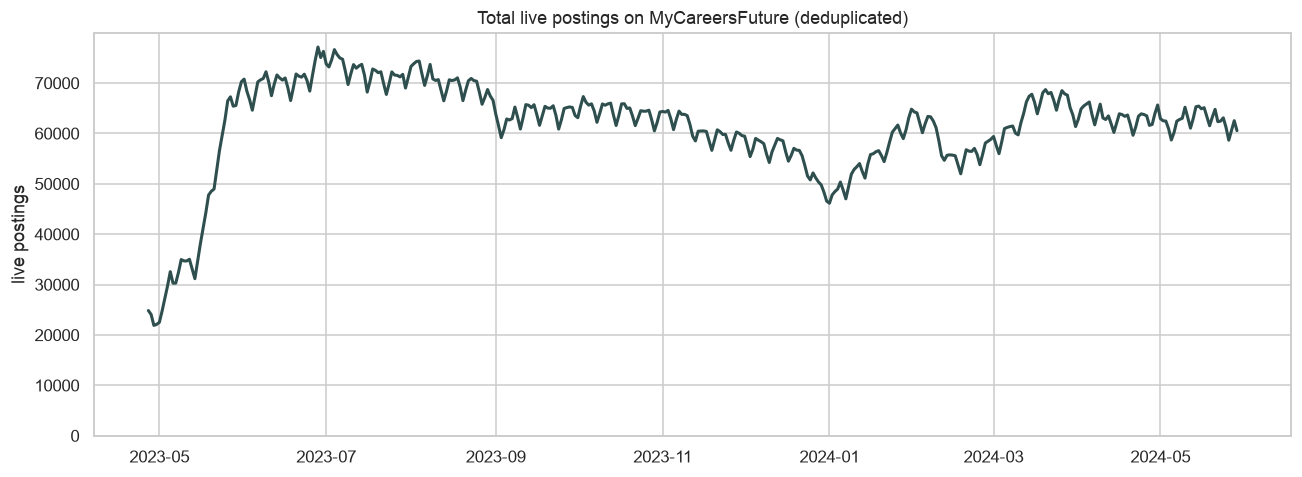

In [14]:
# Total market liquidity over time -- context for the density numbers above.
fig, ax = plt.subplots(figsize=(12, 4.5))
total_live = valid_window.sum(axis=1)
ax.plot(total_live.index, total_live.values, lw=2, color='darkslategray')
ax.set_title('Total live postings on MyCareersFuture (deduplicated)')
ax.set_ylabel('live postings')
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

The total-liquidity curve puts the per-cell numbers in proportion: tens of thousands of postings
are live on any given day, so even the most crowded configuration above holds only a few percent
of the whole market. The series also keeps climbing well past the warmup — listings that outlive
the 30-day cutoff are still accumulating in the early months — so the density medians above lean
slightly conservative rather than inflated.

## 6. Conclusions — and the limits

**1. The market is bottom-heavy, and the level taxonomy does not track pay.**
Across 1,009,709 deduplicated postings the median advertised midpoint is **\$3,800**. The largest
single level, *Executive*, holds **24.4%** of the market at a median of **\$3,750** — below *Senior
Executive* (\$5,000), *Manager* (\$6,050) and *Professional* (\$6,500). On MyCareersFuture
"Executive" is a broad mid-market bucket, not a senior one. A dashboard that orders levels by their
names will mislead; order them by observed pay.

**2. Benchmarks are available at the finest grain almost everywhere.**
867 `sector × position_level × experience_level` cells clear the 30-posting floor and cover
**99.7%** of postings; the `sector × position_level` fallback covers **100%**. Because
`salary_lookup()` degrades between the two, a benchmark can be quoted for practically any
configuration a hirer enters — thin cells are real but rare.

**3. Abnormal configurations are concentrated and identifiable.**
**11 of 63** level × years combinations are used by under 1% of postings at that level, and
they mostly cluster in two recognisable shapes: demanding several years' experience at a junior
level (*Fresh/entry*, *Junior Executive*, *Non-executive*), and demanding no experience at a
senior one (*Senior Management*, *Middle Management*, *Senior Executive*). These are the
combinations worth warning on.

**4. Crowding is concentrated in a handful of configurations.**
Measured across 399 days (late Apr 2023 – May 2024), an *IT / Professional* posting sits alongside
a median of **1,842** comparable live listings, *Admin / Junior Executive* **1,695**, and
*Engineering / Executive* **1,668**. Density needs only posting and expiry dates, which makes it
the one competitive signal computable at full scale.

**5. Two data facts constrain everything above.**
**92.6%** of rows still marked *Open* carry an expiry date already in the past, so
`status_jobStatus` cannot be read as live-versus-closed — this is what forces the counters-complete
split in §1 and confines all response analysis to Layer 2. Salary itself is in good shape:
**99.0%** of the deduplicated market carries a usable range, and deduplication removed **34,878**
copies before any of these figures were computed.

**What a hirer should take from Layer 1.** Set pay against the sector–level–experience percentiles
rather than the level label; check that the years-of-experience requirement is one the market
actually uses at that level; and expect to compete with hundreds to low thousands of comparable
live listings in the busiest configurations.

---

**What this notebook cannot establish.** Nothing about *applicant response*. Layer 1 cannot say
whether a configuration attracts applicants or gets reposted — those columns are frozen at capture
time for most of the file. That is Layer 2, running on the `counters_complete` cohort defined in
§1.1, and it carries a limitation Layer 1 does not: its window is a single three-month slice of
the 2023 labour market, so it supports no seasonality claim.

**Coverage note.** 1,044,587 raw postings, 1,009,709 after deduplication (§1.1); market shape,
configuration norms and density use all of them, and the salary benchmarks use the 999,941
(99.0%) that pass the salary filter (§3). Nothing was dropped silently.